# Delta Analysis: Semantic Mutability of Verbs vs Nouns

Loads `output/verb_noun_deltas.csv` (produced by `compute_deltas.py`) and `data/iRT_AJT.csv`.

**Research Questions**
1. Is |Δverb| > |Δnoun|? (mutability hypothesis)
2. Does Δ predict RT? Does it interact with condition?
3. How does pool size affect the stability of X[word]?

## Roadmap
1. Load data, merge, sanity-check coverage
2. RQ1 — mutability: paired t-test + effect size (Cohen's d)
3. RQ2 — RT regression: Δverb and Δnoun as predictors, interaction with condition
4. Pool-size diagnostics: does cosine drop as more contexts included?
5. Export tidy analysis dataset

In [73]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('..').resolve()
DELTAS_CSV = ROOT / 'output' / 'verb_noun_deltas.csv'
STIMULI    = ROOT / 'data' / 'iRT_AJT.csv'
OUT_DIR    = ROOT / 'output'
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Load and merge

In [74]:
if not DELTAS_CSV.exists():
    raise FileNotFoundError(
        f'Delta CSV not found at {DELTAS_CSV}.\n'
        'Run compute_deltas.py first (requires ~10 GB RAM for loading .pt files).'
    )

deltas  = pd.read_csv(DELTAS_CSV)
stimuli = pd.read_csv(STIMULI)

# deltas already has item, verb, noun, condition, iRT_AJT + all delta metrics
# bring in extra psycholinguistic predictors from stimuli
EXTRA_COLS = ['verb', 'noun', 'noun_concreteness', 'snd3', 'snd10', 'snd25', 'snd50',
              'logDice', 'collocation_freq', 'VerbFreq', 'NounFreq', 'verb_synset_len']
stim_extra = stimuli[[c for c in EXTRA_COLS if c in stimuli.columns]] # only keep columns that are actually present in the stimuli file

df = pd.merge(deltas, stim_extra, on=['verb', 'noun'], how='left')

print(f'Rows: {len(df)}  |  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'verb_delta_cos: {df["verb_delta_cos"].notna().sum()} non-null')
print(f'noun_delta_cos: {df["noun_delta_cos"].notna().sum()} non-null')
df.head()

Rows: 190  |  Conditions: {'Collocation': 95, 'Productive': 95}
verb_delta_cos: 187 non-null
noun_delta_cos: 187 non-null


,item,verb,noun,condition,iRT_AJT,verb_delta_cos,verb_pool_size,verb_apd,verb_n_clusters,verb_samd,...,noun_concreteness,snd3,snd10,snd25,snd50,logDice,collocation_freq,VerbFreq,NounFreq,verb_synset_len
0,abandon projects,abandon,project,Collocation,1182.304348,0.963387,99.0,0.290699,4.0,0.319262,...,3.62,170.17,284.97,344.87,374.52,6.46,18018,430978,214649,5
1,battle diseases,battle,disease,Collocation,1086.217391,0.908115,94.0,0.337814,2.0,0.386767,...,3.45,102.90,195.33,244.79,273.82,6.46,4809,430978,214649,1
2,beat odds,beat,odds,Collocation,967.434783,NaN,NaN,NaN,NaN,NaN,...,2.24,135.59,194.58,215.04,223.92,7.70,12574,430978,214649,23
3,bend rules,bend,rule,Collocation,910.739130,0.885098,94.0,0.273407,2.0,0.336904,...,2.57,177.48,280.06,326.59,358.70,7.08,14612,430978,214649,6
4,break silence,break,silence,Collocation,1035.304348,0.891343,92.0,0.328948,3.0,0.411795,...,3.33,107.25,151.56,168.73,179.07,8.54,53167,430978,214649,59


In [75]:
# Items with complete data (both deltas available)
df_complete = df.dropna(subset=['verb_delta_cos', 'noun_delta_cos', 'iRT_AJT']).copy()
print(f'Complete cases (both deltas + RT): {len(df_complete)}')
print(df_complete['condition'].value_counts())

# print which items are missing verb or noun deltas
missing_verb = df[df['verb_delta_cos'].isna()]
missing_noun = df[df['noun_delta_cos'].isna()]
print(f'Items missing verb delta: {len(missing_verb)}')
print(f'Items missing noun delta: {len(missing_noun)}')
print('Items missing verb delta:')
print(missing_verb[['item', 'verb', 'noun', 'condition']])
print('Items missing noun delta:')
print(missing_noun[['item', 'verb', 'noun', 'condition']])  

Complete cases (both deltas + RT): 187
condition
Collocation    94
Productive     93
Name: count, dtype: int64
Items missing verb delta: 3
Items missing noun delta: 3
Items missing verb delta:
                item     verb     noun    condition
2          beat odds     beat     odds  Collocation
113        dent cans     dent      can   Productive
140  launder clothes  launder  clothes   Productive
Items missing noun delta:
                item     verb     noun    condition
2          beat odds     beat     odds  Collocation
113        dent cans     dent      can   Productive
140  launder clothes  launder  clothes   Productive


---
## 2. RQ1 — Mutability: |Δverb| vs |Δnoun|

Hypothesis: verbs (relational categories) show greater deviation from their prototype embedding than nouns (entity categories), i.e., verb cosine similarity to the global mean is *lower* than for nouns.

Note: a *lower* cosine similarity = more context-shift = greater mutability.

In [76]:
d = df_complete

# Summary stats
print('=== Delta cosine similarity (higher = more similar to prototype = less mutable) ===')
print(d[['verb_delta_cos', 'noun_delta_cos']]
      .describe().round(4).to_string())

print('\n=== By condition ===')
print(d.groupby('condition')[['verb_delta_cos', 'noun_delta_cos']]
      .mean().round(4).to_string())

=== Delta cosine similarity (higher = more similar to prototype = less mutable) ===
       verb_delta_cos  noun_delta_cos
count        187.0000        187.0000
mean           0.9082          0.9715
std            0.0660          0.0305
min            0.6183          0.6926
25%            0.8764          0.9660
50%            0.9250          0.9805
75%            0.9596          0.9873
max            0.9911          0.9984

=== By condition ===
             verb_delta_cos  noun_delta_cos
condition                                  
Collocation          0.8861          0.9711
Productive           0.9305          0.9718


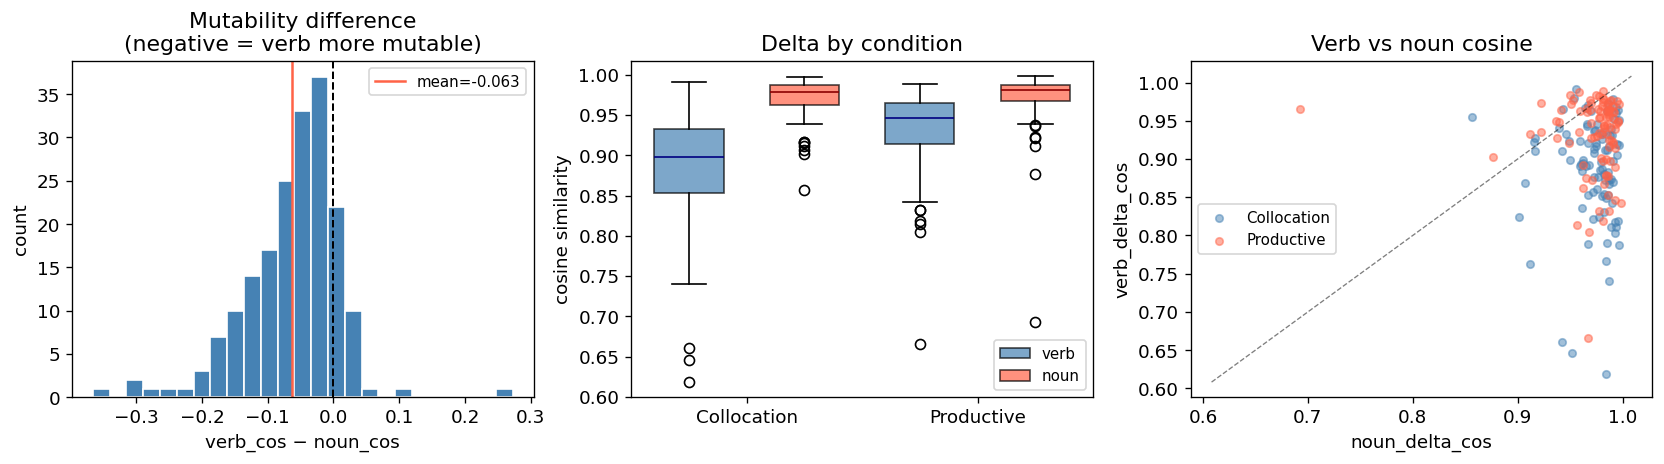

Saved rq1_mutability.png


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Paired difference distribution
ax = axes[0]
diff_all = d['verb_delta_cos'] - d['noun_delta_cos']
ax.hist(diff_all, bins=25, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.axvline(diff_all.mean(), color='tomato', lw=1.5, label=f'mean={diff_all.mean():.3f}')
ax.set(xlabel='verb_cos − noun_cos', ylabel='count', title='Mutability difference\n(negative = verb more mutable)')
ax.legend(fontsize=9)

# 2. Boxplot by condition
ax = axes[1]
conds = ['Collocation', 'Productive']
data_v = [d.loc[d['condition']==c, 'verb_delta_cos'].dropna() for c in conds]
data_n = [d.loc[d['condition']==c, 'noun_delta_cos'].dropna() for c in conds]
pos_v = [1, 3]
pos_n = [2, 4]
bp1 = ax.boxplot(data_v, positions=pos_v, widths=0.6, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.7), medianprops=dict(color='navy'))
bp2 = ax.boxplot(data_n, positions=pos_n, widths=0.6, patch_artist=True,
                 boxprops=dict(facecolor='tomato', alpha=0.7), medianprops=dict(color='darkred'))
ax.set_xticks([1.5, 3.5])
ax.set_xticklabels(conds)
ax.set(ylabel='cosine similarity', title='Delta by condition')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['verb', 'noun'], fontsize=9)

# 3. Scatter: verb_delta vs noun_delta, coloured by condition
ax = axes[2]
colours = {'Collocation': 'steelblue', 'Productive': 'tomato'}
for cond, grp in d.groupby('condition'):
    ax.scatter(grp['noun_delta_cos'], grp['verb_delta_cos'],
               c=colours[cond], alpha=0.5, s=20, label=cond)
lims = [min(d['verb_delta_cos'].min(), d['noun_delta_cos'].min()) - 0.01,
        max(d['verb_delta_cos'].max(), d['noun_delta_cos'].max()) + 0.01]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
ax.set(xlabel='noun_delta_cos', ylabel='verb_delta_cos', title='Verb vs noun cosine')
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUT_DIR / 'rq1_mutability.png', bbox_inches='tight')
plt.show()
print('Saved rq1_mutability.png')

In [72]:

# Outliers in mutability delta (verb_cos - noun_cos)
diff_all = d['verb_delta_cos'] - d['noun_delta_cos']

q1, q3 = diff_all.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = d[['verb', 'noun', 'condition', 'verb_delta_cos', 'noun_delta_cos']].copy()
outliers['diff'] = diff_all
outliers = outliers[(diff_all < lo) | (diff_all > hi)].sort_values('diff')

print(f'IQR fence: [{lo:.3f}, {hi:.3f}]  |  {len(outliers)} outliers')
outliers.round(4)


IQR fence: [-0.223, 0.102]  |  6 outliers


,verb,noun,condition,verb_delta_cos,noun_delta_cos,diff
7,carry,risk,Collocation,0.6183,0.9842,-0.3660
8,cast,doubt,Collocation,0.6458,0.9523,-0.3065
119,face,window,Productive,0.6657,0.9672,-0.3015
9,catch,attention,Collocation,0.6603,0.9423,-0.2820
80,stir,controversy,Collocation,0.7401,0.9870,-0.2468
145,navigate,water,Productive,0.9652,0.6926,0.2726


---
## 3. RQ2 — Does Δ predict RT?

Hypothesis (from pilot with 10 nouns): as cosine similarity decreases (more context shift), RT increases — but only for collocations, not productive items.

We fit linear mixed models (via OLS on item-level means here; trial-level models need `data/experiment_data_anonymised.csv`).

Models:
- M0: `iRT_AJT ~ verb_delta_cos`
- M1: `iRT_AJT ~ noun_delta_cos`
- M2: `iRT_AJT ~ verb_delta_cos * condition`
- M3: `iRT_AJT ~ noun_delta_cos * condition`
- M4: `iRT_AJT ~ verb_delta_cos + noun_delta_cos + condition` (additive)
- M5: `iRT_AJT ~ (verb_delta_cos + noun_delta_cos) * condition` (full interaction)

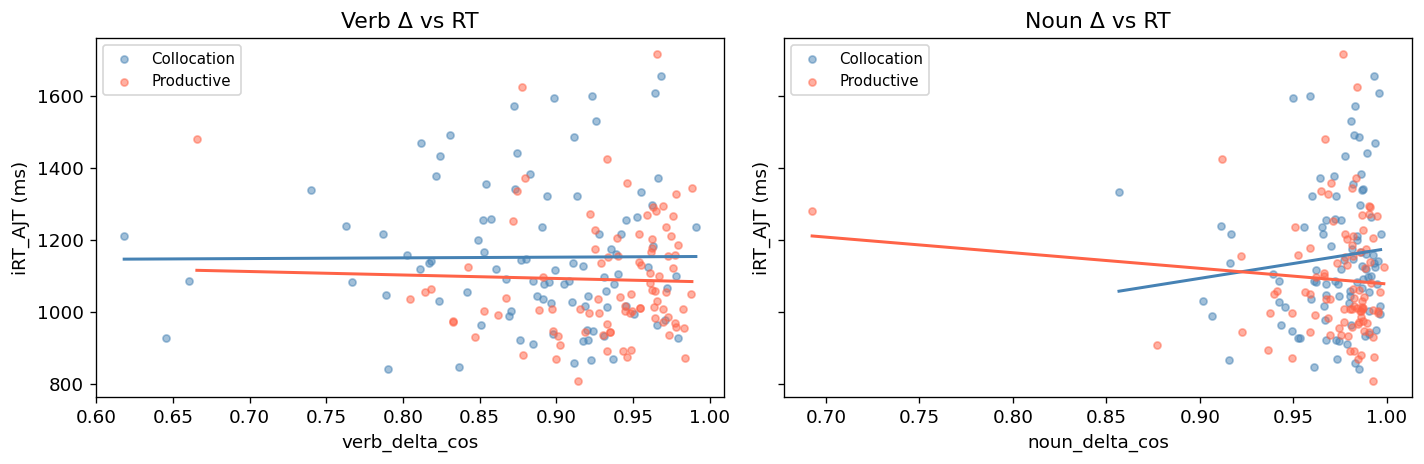

Saved rq2_rt_regression.png


In [78]:
# Visualise: delta ~ RT by condition
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, delta_col, title in zip(
        axes,
        ['verb_delta_cos', 'noun_delta_cos'],
        ['Verb Δ vs RT', 'Noun Δ vs RT']):

    for cond, colour in [('Collocation', 'steelblue'), ('Productive', 'tomato')]:
        grp = df_complete[df_complete['condition'] == cond].dropna(subset=[delta_col, 'iRT_AJT'])
        ax.scatter(grp[delta_col], grp['iRT_AJT'], c=colour, alpha=0.5, s=18, label=cond)
        m, b = np.polyfit(grp[delta_col], grp['iRT_AJT'], 1)
        xs = np.linspace(grp[delta_col].min(), grp[delta_col].max(), 100)
        ax.plot(xs, m * xs + b, color=colour, lw=1.8)

    ax.set(xlabel=delta_col, ylabel='iRT_AJT (ms)', title=title)
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUT_DIR / 'rq2_rt_regression.png', bbox_inches='tight')
plt.show()
print('Saved rq2_rt_regression.png')

---
## 4. Pool-size diagnostics

A key concern: larger pools → more stable (closer to corpus-wide) X[word], potentially artefactually lower cosine similarity. We check whether pool size correlates with delta cosine within each condition.

In [79]:
print('=== Verb pool size ===')
print(df_complete['verb_pool_size'].describe().round(1))

print('\n=== Noun pool size (−1 = from verbs fallback) ===')
print(df_complete['noun_pool_size'].describe().round(1))
print(df_complete['noun_x_source'].value_counts())

=== Verb pool size ===
count    187.0
mean      83.7
std       17.0
min       23.0
25%       80.5
50%       90.0
75%       94.0
max       99.0
Name: verb_pool_size, dtype: float64

=== Noun pool size (−1 = from verbs fallback) ===
count    187.0
mean      86.6
std       18.0
min        8.0
25%       87.0
50%       93.0
75%       97.0
max       99.0
Name: noun_pool_size, dtype: float64
Series([], Name: count, dtype: int64)


In [80]:
# Correlation: pool size vs delta cosine
for word, pool_col, delta_col in [
        ('verb', 'verb_pool_size', 'verb_delta_cos'),
        ('noun', 'noun_pool_size', 'noun_delta_cos')]:

    sub = df_complete[[pool_col, delta_col]].dropna()
    r, p = stats.pearsonr(sub[pool_col], sub[delta_col])
    print(f'{word:>4} pool_size vs delta_cos:  r = {r:+.3f},  p = {p:.4f}  (n={len(sub)})')

verb pool_size vs delta_cos:  r = -0.110,  p = 0.1348  (n=187)
noun pool_size vs delta_cos:  r = -0.241,  p = 0.0009  (n=187)


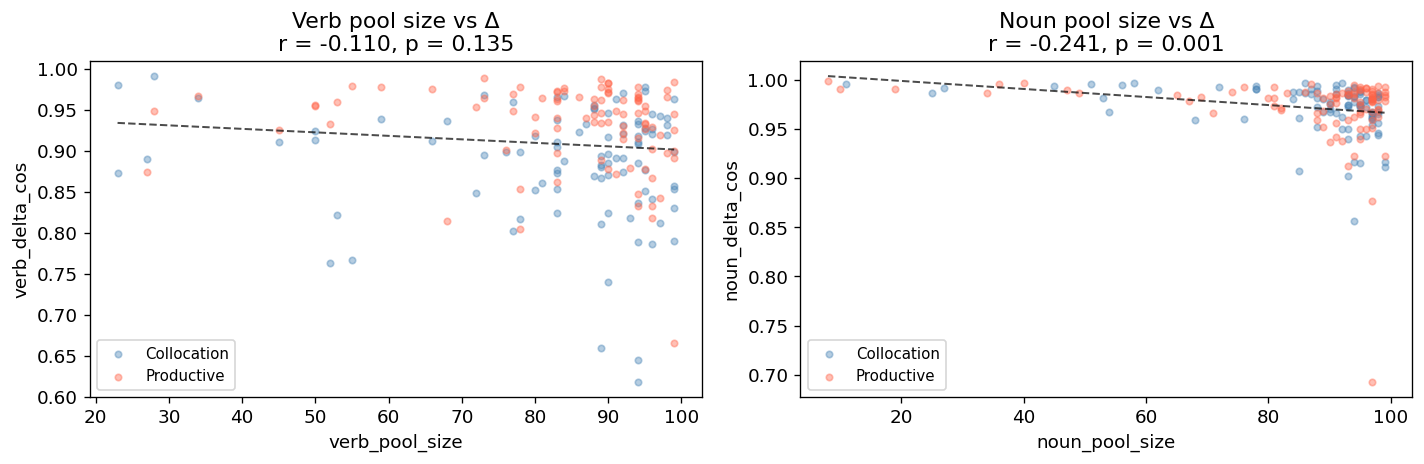

Saved rq3_pool_size.png


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pool_col, delta_col, label in zip(
        axes,
        ['verb_pool_size', 'noun_pool_size'],
        ['verb_delta_cos', 'noun_delta_cos'],
        ['Verb', 'Noun']):

    sub = df_complete[[pool_col, delta_col, 'condition']].dropna()
    for cond, colour in [('Collocation', 'steelblue'), ('Productive', 'tomato')]:
        grp = sub[sub['condition'] == cond]
        ax.scatter(grp[pool_col], grp[delta_col], c=colour, alpha=0.4, s=15, label=cond)

    m, b = np.polyfit(sub[pool_col], sub[delta_col], 1)
    xs = np.linspace(sub[pool_col].min(), sub[pool_col].max(), 100)
    ax.plot(xs, m * xs + b, 'k--', lw=1.2, alpha=0.7)
    r, p = stats.pearsonr(sub[pool_col], sub[delta_col])
    ax.set(xlabel=pool_col, ylabel=delta_col,
           title=f'{label} pool size vs Δ\nr = {r:+.3f}, p = {p:.3f}')
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUT_DIR / 'rq3_pool_size.png', bbox_inches='tight')
plt.show()
print('Saved rq3_pool_size.png')

---
## 5. Export tidy analysis dataset

In [82]:
EXPORT_COLS = [
    'item', 'verb', 'noun', 'condition', 'iRT_AJT',
    'verb_delta_cos', 'verb_pool_size',
    'noun_delta_cos', 'noun_pool_size', 'noun_x_source',
    'noun_concreteness', 'snd3', 'snd10', 'snd25', 'snd50',
    'logDice', 'collocation_freq', 'VerbFreq', 'NounFreq',
    'verb_synset_len',
]
existing = [c for c in EXPORT_COLS if c in df_complete.columns]
out = df_complete[existing].copy()

out_path = OUT_DIR / 'analysis_dataset.csv'
out.to_csv(out_path, index=False)
print(f'Saved -> {out_path}  ({len(out)} rows, {len(existing)} columns)')
out.head()

Saved -> C:\Users\psyde\OneDrive\Documents\GitHub\SemShift\output\analysis_dataset.csv  (187 rows, 20 columns)


,item,verb,noun,condition,iRT_AJT,verb_delta_cos,verb_pool_size,noun_delta_cos,noun_pool_size,noun_x_source,noun_concreteness,snd3,snd10,snd25,snd50,logDice,collocation_freq,VerbFreq,NounFreq,verb_synset_len
0,abandon projects,abandon,project,Collocation,1182.304348,0.963387,99.0,0.970111,90.0,NaN,3.62,170.17,284.97,344.87,374.52,6.46,18018,430978,214649,5
1,battle diseases,battle,disease,Collocation,1086.217391,0.908115,94.0,0.972546,93.0,NaN,3.45,102.90,195.33,244.79,273.82,6.46,4809,430978,214649,1
3,bend rules,bend,rule,Collocation,910.739130,0.885098,94.0,0.978790,96.0,NaN,2.57,177.48,280.06,326.59,358.70,7.08,14612,430978,214649,6
4,break silence,break,silence,Collocation,1035.304348,0.891343,92.0,0.959634,76.0,NaN,3.33,107.25,151.56,168.73,179.07,8.54,53167,430978,214649,59
5,build trust,build,trust,Collocation,842.260870,0.790223,99.0,0.985292,95.0,NaN,2.04,146.80,212.51,243.01,258.24,7.64,79084,430978,214649,10


---\n## 6. Statistical models → `analysis.R`\n\nAll t-tests, mixed models, and OLS regressions are in `analysis.R`.\nRun the cell below **after the export above** so `output/analysis_dataset.csv` exists.\nRequires R + lme4 + lmerTest + effectsize + tidyverse.

In [83]:
import subprocess, sys
from pathlib import Path

RSCRIPT = Path("C:/Program Files/R/R-4.4.1/bin/Rscript.exe")

result = subprocess.run(
    [str(RSCRIPT), str(ROOT / "analysis.R")],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print("--- STDERR ---", file=sys.stderr)
    print(result.stderr, file=sys.stderr)

Item-level data: 187 rows
Trial-level data: 4365 rows


====== RQ1: Paired t-test (verb vs noun delta cosine) ======

	Paired t-test

data:  item$verb_delta_cos and item$noun_delta_cos
t = -11.741, df = 186, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.07388449 -0.05262778
sample estimates:
mean difference 
    -0.06325613 

Cohen's d: -0.859 
Interpretation: negative d => verb cos < noun cos => verbs MORE mutable (predicted)

--- By condition ---
   Collocation  n=94  t=-10.904  p=0.0000  d=-1.125
    Productive  n=93  t=-6.123  p=0.0000  d=-0.635


====== RQ1b: Mixed model (word_type Ã— condition) ======
Long format: 374 rows

--- M_base (no covariates) ---
Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: delta_cos ~ word_type * condition + (1 | item)
   Data: long

     AIC      BIC   logLik deviance df.resid 
 -1185.8  -1162.2    598.9  -1197.8      

---
## 6. Interpretation checklist

Fill in after running:

- [ ] RQ1: Is verb_delta_cos significantly < noun_delta_cos? (t-test direction and p)
- [ ] RQ1: Does the effect hold within each condition separately?
- [ ] RQ2: Does any model explain meaningful RT variance (adj-R² > 0.05)?
- [ ] RQ2: Is the verb_delta_cos × condition interaction significant? (replication of pilot)
- [ ] RQ2: Is the noun_delta_cos × condition interaction significant?
- [ ] Pool size: Is there a significant negative correlation between pool_size and delta_cos? If so, consider partial-correlation or residualisation.
- [ ] Noun fallback items: do items with `noun_x_source == 'verbs_pt_fallback'` behave differently? (spot-check with groupby)
- [ ] Missing items: confirm the 3 known exclusions (beat odds, dent cans, launder clothes) are absent from df_complete